# Evaluate the models

Imports

In [15]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from lightgbm import LGBMClassifier

## Load the cleaned data

In [16]:
# load from csv
df = pd.read_csv("data/processed_crime_traffic_accidents.csv")

# force all columns to be strings (except the target variable)
for col in df.columns:
    if col != "high_risk":
        df[col] = df[col].astype(str)

# split into X and y
y = df["high_risk"]
X = df.drop(columns=["high_risk"])

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1234,
    stratify=y,      # keep class balance in both splits
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# force all columns to be strings (except the target variable)
for col in df.columns:
    if col != "high_risk":
        df[col] = df[col].astype(str)

# all the data is categorical, one-hot encode everything
encoder = OneHotEncoder(handle_unknown="ignore")
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

X_train shape: (225795, 29)
X_test shape: (56449, 29)
X_train_encoded shape: (225795, 976)
X_test_encoded shape: (56449, 976)


## Precision / Recall / F1 on per-model basis

In [17]:
def evaluate_model(model, X_test, y_test):
    print(f"Model: {repr(model)}")
    y_pred_test = model.predict(X_test)
    print(classification_report(y_test, y_pred_test, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    print("\n")

# extra trees
with open(f"./pickle_jar/et_model_final.pkl", "rb") as f:
    et_model = pickle.load(f)
evaluate_model(et_model, X_test_encoded, y_test)


# random forest
with open(f"./pickle_jar/rf_model_final.pkl", "rb") as f:
    rf_model = pickle.load(f)
evaluate_model(rf_model, X_test_encoded, y_test)


# logistic regression
with open(f"./pickle_jar/lr_model_final.pkl", "rb") as f:
    lr_model = pickle.load(f)
evaluate_model(lr_model, X_test_encoded, y_test)


# Linear SVC
with open(f"./pickle_jar/svc_model_final.pkl", "rb") as f:
    svc_model = pickle.load(f)
evaluate_model(svc_model, X_test_encoded, y_test)


# LightGBM
with open(f"./pickle_jar/lgbm_model_final.pkl", "rb") as f:
    lgbm_model = pickle.load(f)
# this model prefers categorical features to be encoded as 'category' dtype instead of one-hot encoding, so we need to convert the test set back to a dataframe and change the dtypes
lgbm_X_test = X_test.copy()
for col in lgbm_X_test.columns:
    lgbm_X_test[col] = lgbm_X_test[col].astype('category')
evaluate_model(lgbm_model, lgbm_X_test, y_test)

Model: ExtraTreesClassifier(class_weight='balanced', min_samples_leaf=5,
                     n_estimators=500, n_jobs=-1, random_state=1234)
              precision    recall  f1-score   support

           0     0.9878    0.9688    0.9782     55137
           1     0.2739    0.4954    0.3528      1312

    accuracy                         0.9577     56449
   macro avg     0.6308    0.7321    0.6655     56449
weighted avg     0.9712    0.9577    0.9636     56449

Confusion Matrix:
[[53414  1723]
 [  662   650]]


Model: RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=500, n_jobs=-1, oob_score=True,
                       random_state=1234)
              precision    recall  f1-score   support

           0     0.9872    0.9726    0.9799     55137
           1     0.2906    0.4710    0.3594      1312

    accuracy                         0.9610     56449
   macro avg     0.6389    0.7218    0.6696     56449
weighted avg     0.9710

## ROC and Precision / Recall graphs on per-model basis

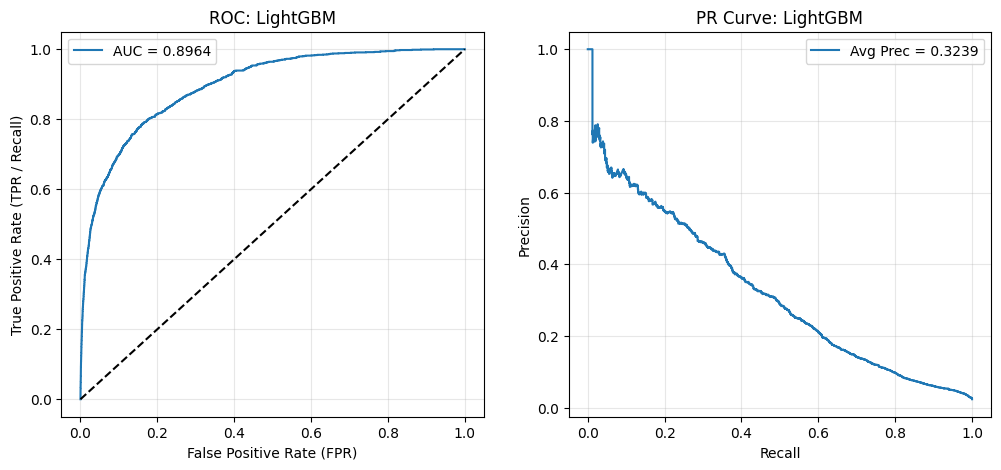

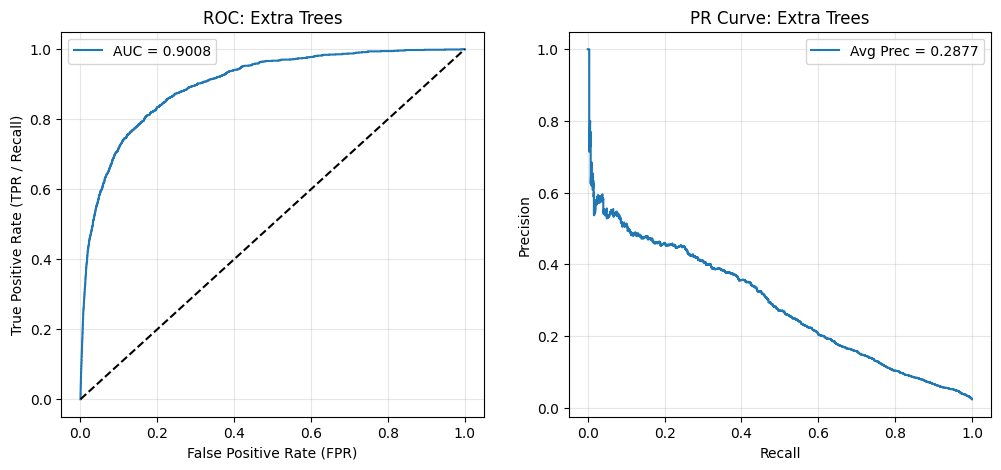

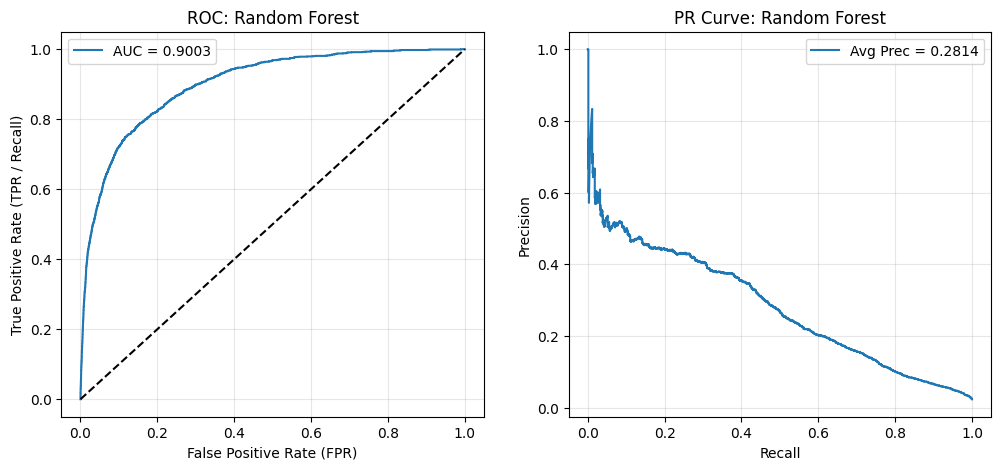

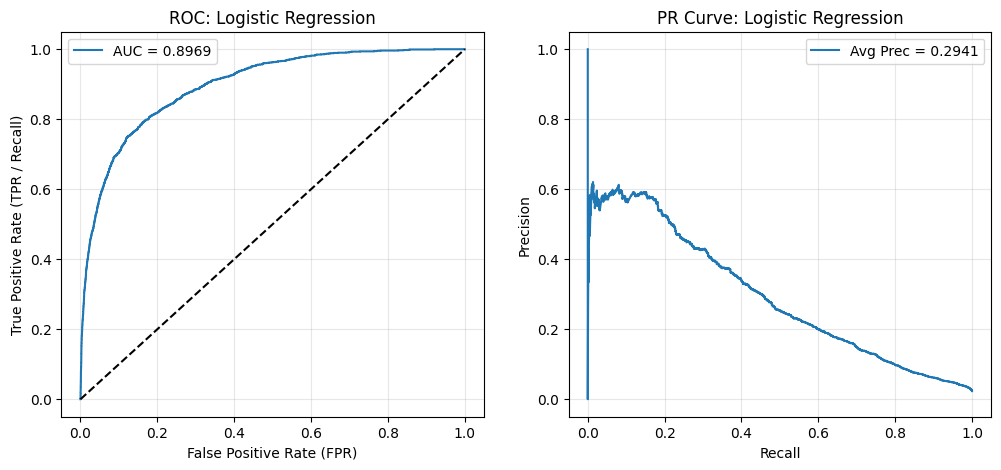

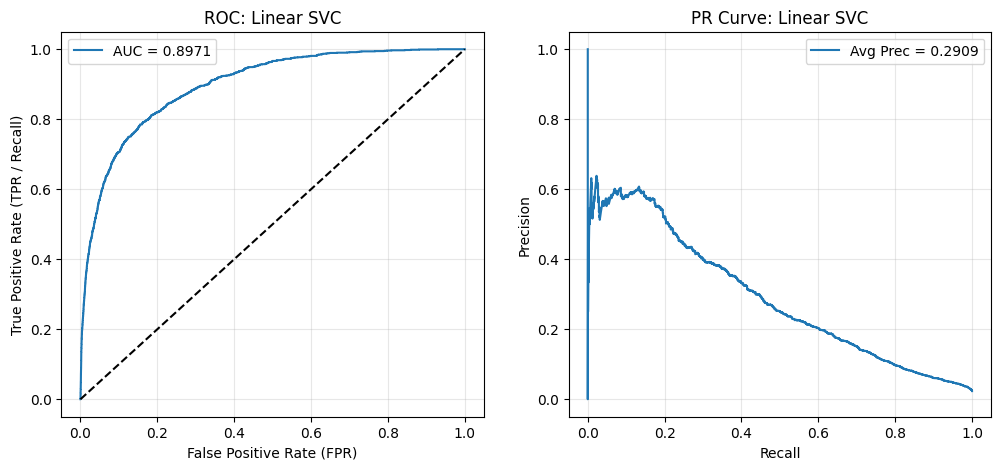

In [24]:
def plot_curves(model, X_test, y_test, model_name):
    # Get scores: predict_proba for most, decision_function for SVC
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)
    
    # 1. Calculate ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    # 2. Calculate PR
    precision, recall, _ = precision_recall_curve(y_test, probs)
    avg_prec = average_precision_score(y_test, probs)
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    ax1.plot([0, 1], [0, 1], 'k--')
    ax1.set_title(f'ROC: {model_name}')
    ax1.set_xlabel('False Positive Rate (FPR)')
    ax1.set_ylabel('True Positive Rate (TPR / Recall)')
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    ax2.plot(recall, precision, label=f'Avg Prec = {avg_prec:.4f}')
    ax2.set_title(f'PR Curve: {model_name}')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend(loc="lower left")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.show()

# Run it for your MVP
plot_curves(lgbm_model, lgbm_X_test, y_test, "LightGBM")
plot_curves(et_model, X_test_encoded, y_test, "Extra Trees")
plot_curves(rf_model, X_test_encoded, y_test, "Random Forest")
plot_curves(lr_model, X_test_encoded, y_test, "Logistic Regression")
plot_curves(svc_model, X_test_encoded, y_test, "Linear SVC")

# Feature importance on per model basis

We can see that 

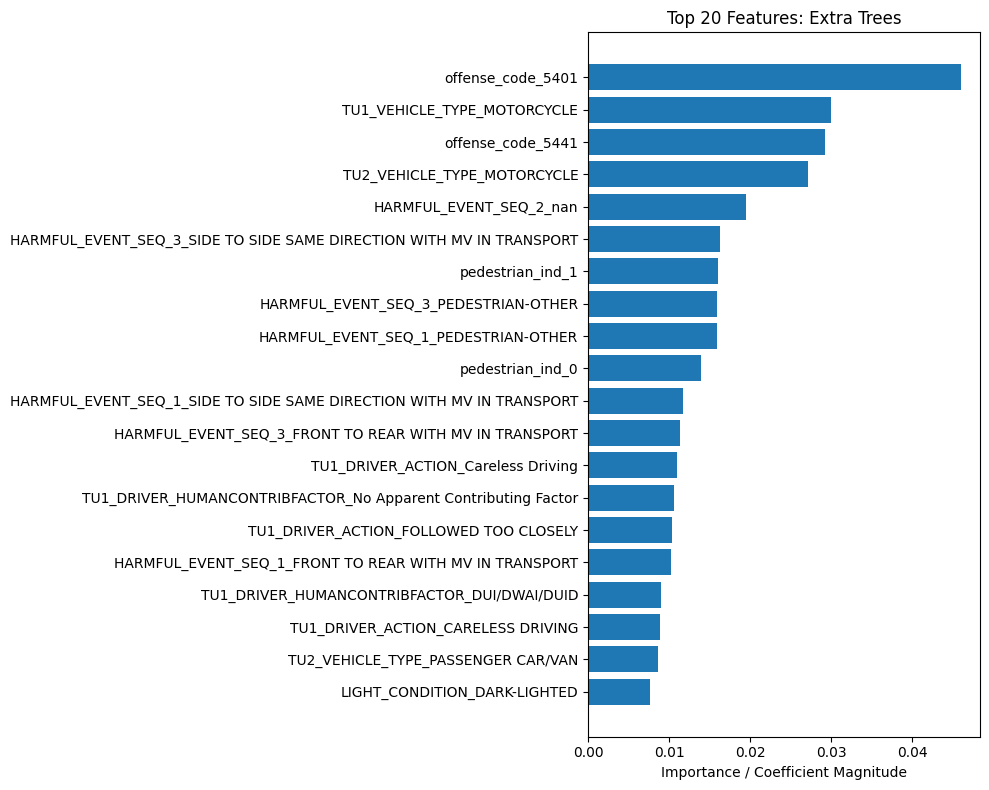

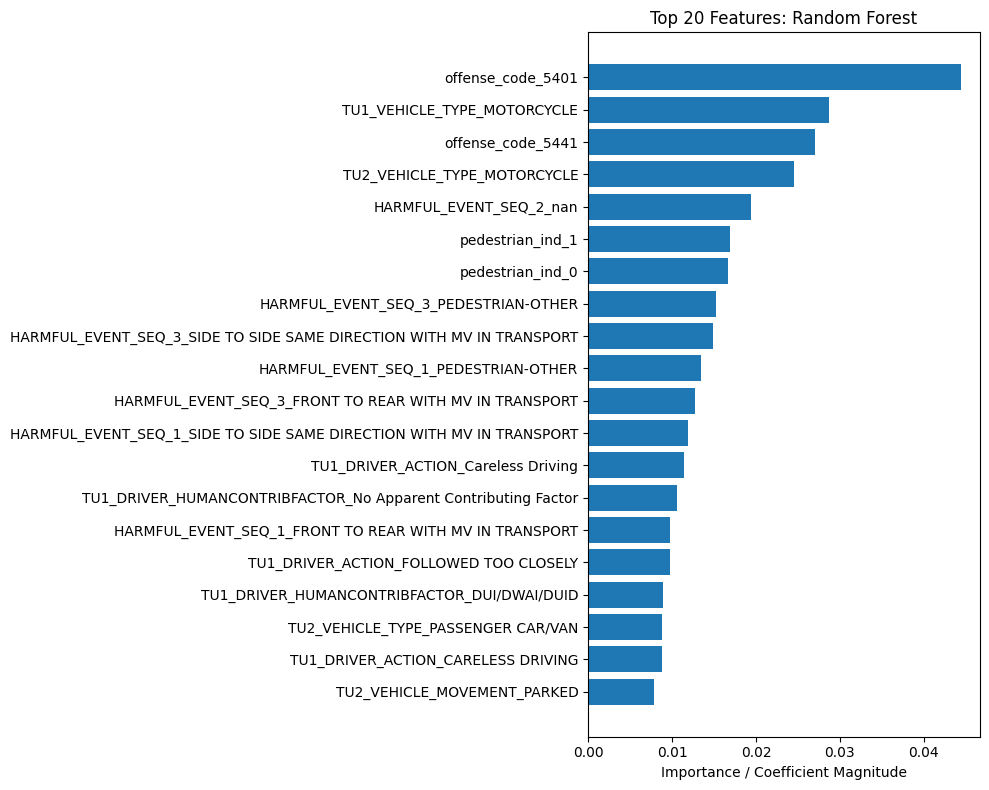

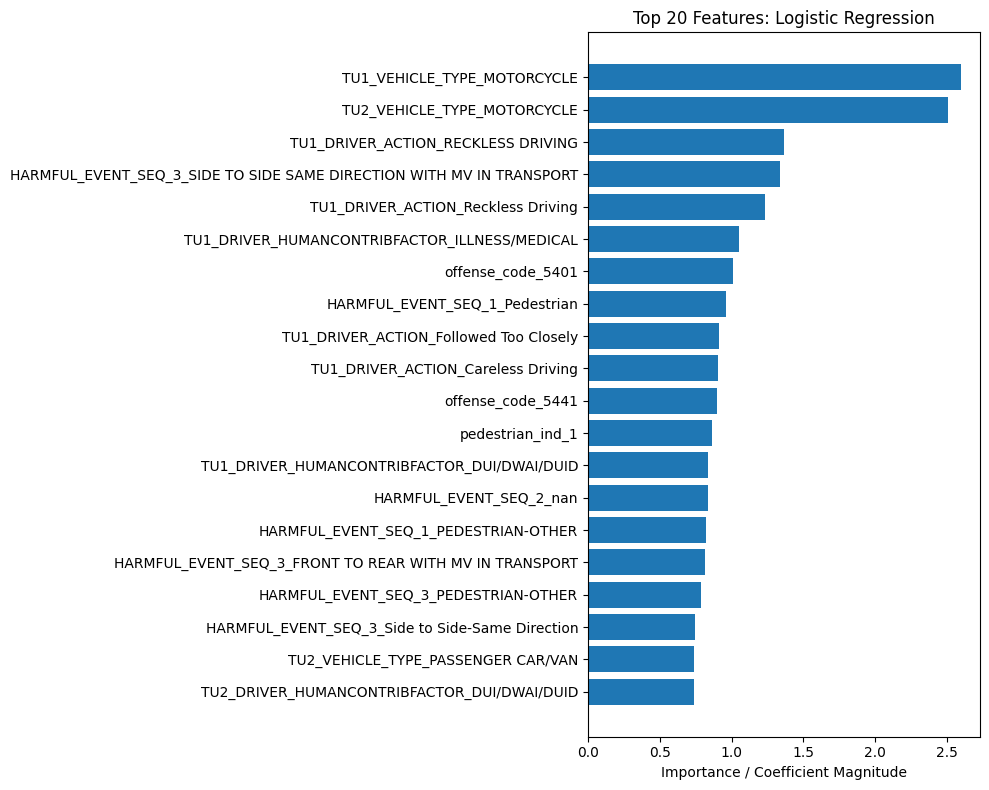

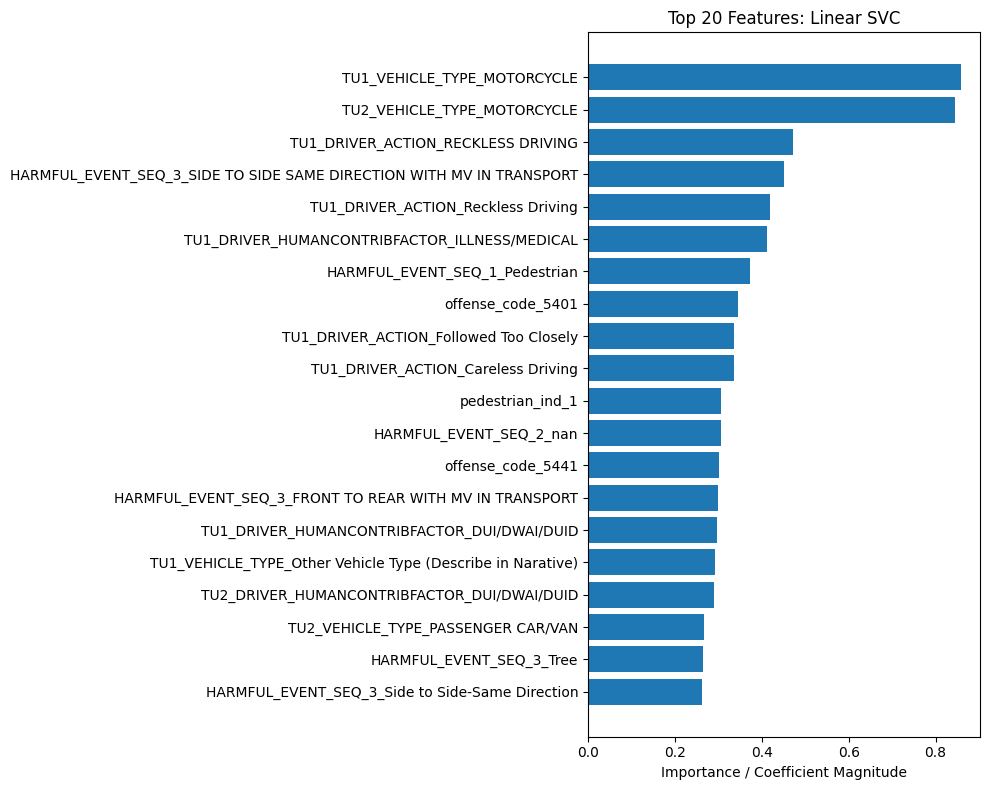

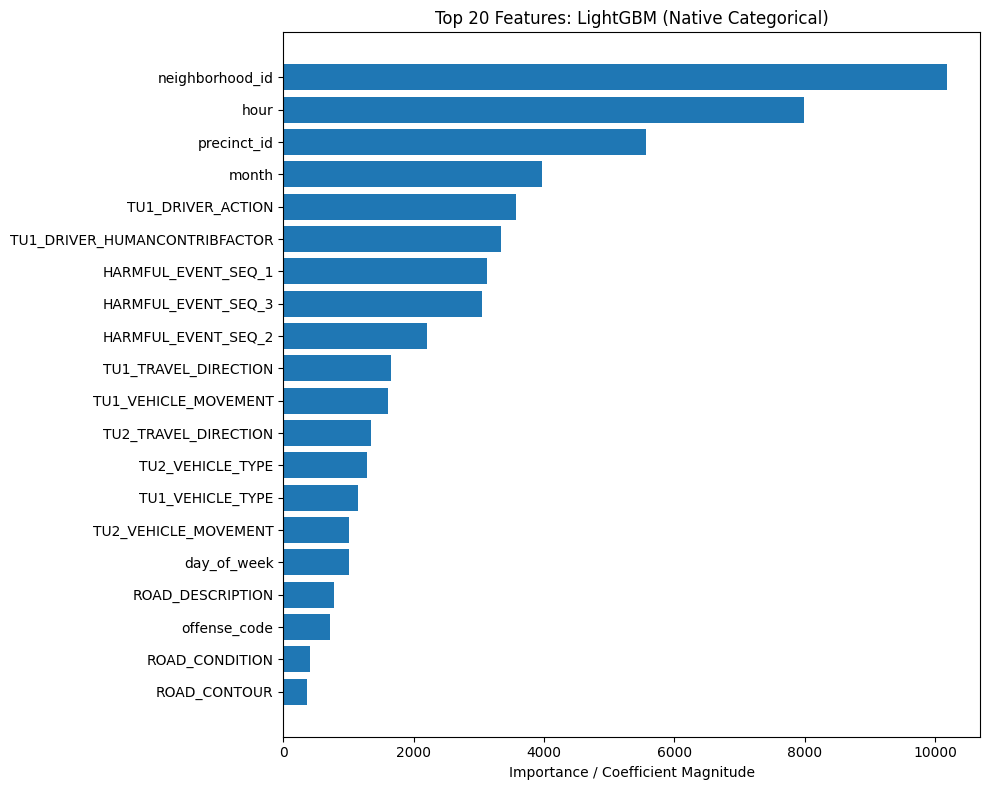

In [19]:
# 1. Get the feature names for the One-Hot Encoded models
# This turns the 29 original columns into the ~980 encoded column names
ohe_feature_names = encoder.get_feature_names_out()

def plot_importance(importance_df, model_name):
    plt.figure(figsize=(10, 8))
    # Taking top 20 for readability given you have nearly 1000 columns
    top_20 = importance_df.head(20)
    plt.barh(top_20['feature'], top_20['importance'])
    plt.gca().invert_yaxis() # Put the most important at the top
    plt.title(f"Top 20 Features: {model_name}")
    plt.xlabel("Importance / Coefficient Magnitude")
    plt.tight_layout()
    plt.show()

# --- Tree-Based Models (OHE) ---
# Extra Trees and Random Forest use .feature_importances_
for model, name in [(et_model, "Extra Trees"), (rf_model, "Random Forest")]:
    imp_df = pd.DataFrame({
        'feature': ohe_feature_names,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)
    plot_importance(imp_df, name)

# --- Linear Models (OHE) ---
# Logistic Regression and Linear SVC use .coef_ (coefficients)
# We take the absolute value to show impact regardless of direction
for model, name in [(lr_model, "Logistic Regression"), (svc_model, "Linear SVC")]:
    imp_df = pd.DataFrame({
        'feature': ohe_feature_names,
        'importance': abs(model.coef_[0])
    }).sort_values(by='importance', ascending=False)
    plot_importance(imp_df, name)

# --- LightGBM (Original Categories) ---
# Note: This model used the raw column names from X, not the OHE columns
lgbm_imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values(by='importance', ascending=False)
plot_importance(lgbm_imp_df, "LightGBM (Native Categorical)")

## Ensemble model (soft voting based on `predict_proba()`)

In [20]:
print("Generating probabilities...")
et_probas = et_model.predict_proba(X_test_encoded)
rf_probas = rf_model.predict_proba(X_test_encoded)
lr_probas = lr_model.predict_proba(X_test_encoded)
lgbm_probas = lgbm_model.predict_proba(lgbm_X_test)

# Apply the custom weights: ET(1), RF(2), LR(1), LGBM(4)
weights = [1, 2, 1, 4]
total_weight = sum(weights)

print(f"Applying Soft Voting with weights: {weights}")
weighted_probas = (
    (et_probas * weights[0]) + 
    (rf_probas * weights[1]) + 
    (lr_probas * weights[2]) + 
    (lgbm_probas * weights[3])
) / total_weight

# Convert averaged probabilities back into 0 or 1 predictions (0.5 threshold)
ensemble_preds = np.argmax(weighted_probas, axis=1)

print("\n--- Results for Weighted Soft Voting Ensemble ---")
print(classification_report(y_test, ensemble_preds, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, ensemble_preds))

Generating probabilities...
Applying Soft Voting with weights: [1, 2, 1, 4]

--- Results for Weighted Soft Voting Ensemble ---
              precision    recall  f1-score   support

           0     0.9886    0.9647    0.9765     55137
           1     0.2645    0.5343    0.3539      1312

    accuracy                         0.9546     56449
   macro avg     0.6266    0.7495    0.6652     56449
weighted avg     0.9718    0.9546    0.9620     56449

Confusion Matrix:
[[53188  1949]
 [  611   701]]


## Ensemble results with modified threshold of `0.55`

In [21]:
# isolate the positive prediction probabilities (for the 'high risk' class)
positive_class_probas = weighted_probas[:, 1]

# choose based on threshold
threshold = 0.55
ensemble_preds_thresholded = (positive_class_probas >= threshold).astype(int)

print(f"--- Results for Weighted Soft Voting Ensemble (Threshold: {threshold}) ---")
print(classification_report(y_test, ensemble_preds_thresholded, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, ensemble_preds_thresholded))

--- Results for Weighted Soft Voting Ensemble (Threshold: 0.55) ---
              precision    recall  f1-score   support

           0     0.9880    0.9722    0.9800     55137
           1     0.3006    0.5023    0.3761      1312

    accuracy                         0.9613     56449
   macro avg     0.6443    0.7372    0.6781     56449
weighted avg     0.9720    0.9613    0.9660     56449

Confusion Matrix:
[[53604  1533]
 [  653   659]]


## ROC and Precision / Recall graphs for the Ensemble model

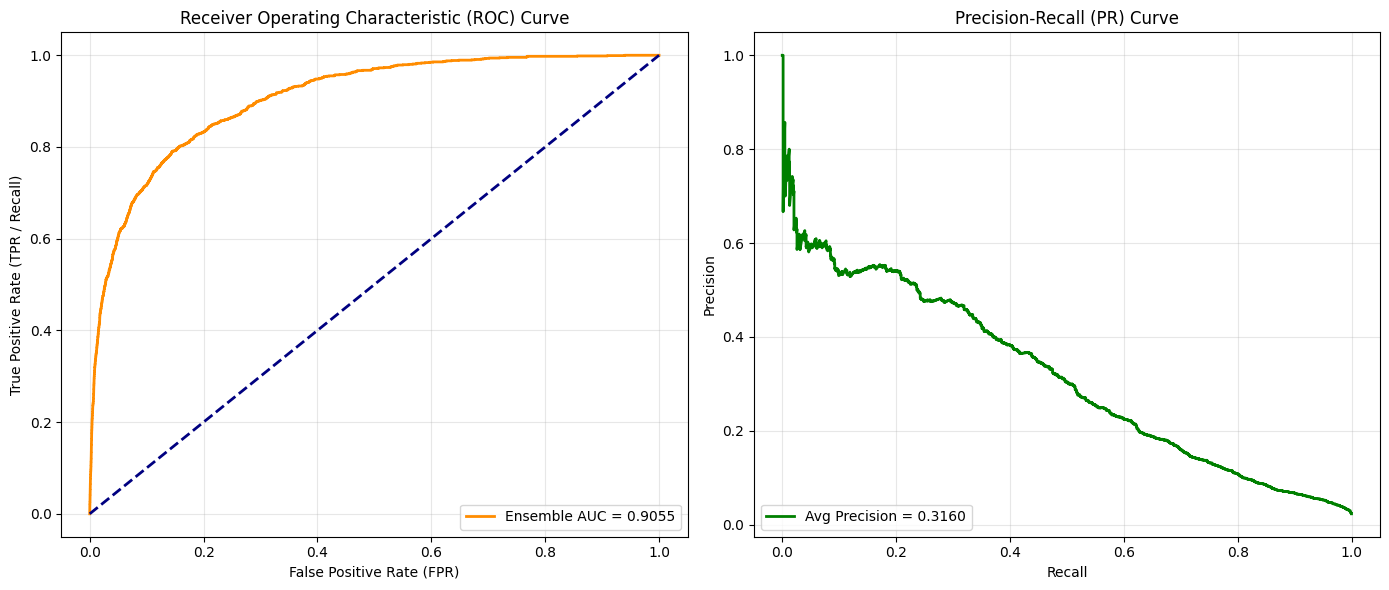

In [22]:
# 1. Extract the probabilities for the positive class (Class 1: hi)
ensemble_pos_probs = weighted_probas[:, 1]

# 2. Calculate ROC Curve metrics
fpr, tpr, roc_thresholds = roc_curve(y_test, ensemble_pos_probs)
roc_auc = auc(fpr, tpr)

# 3. Calculate Precision-Recall Curve metrics (Crucial for your imbalanced data)
precision, recall, pr_thresholds = precision_recall_curve(y_test, ensemble_pos_probs)
avg_precision = average_precision_score(y_test, ensemble_pos_probs)

# 4. Plot both curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'Ensemble AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR / Recall)')
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Right Plot: Precision-Recall Curve
ax2.plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_precision:.4f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall (PR) Curve')
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()